In [ ]:
!pip install -q gdown inference-gpu
!pip list | grep supervision

supervision                              0.27.0


In [ ]:
!pip install tokenizers==0.22.1

In [ ]:
from typing import Optional, List, Generator, Iterable, List, TypeVar, Tuple

import cv2
import supervision as sv
import numpy as np
import torch
import umap
from sklearn.cluster import KMeans
from tqdm import tqdm
from transformers import AutoProcessor, SiglipVisionModel
import numpy.typing as npt
from collections import defaultdict, deque


In [ ]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

In [ ]:
!gdown -O "0bfacc_0.mp4" "https://drive.google.com/uc?id=12TqauVZ9tLAv8kWxTTBFWtgt2hNQ4_ZF"
!gdown -O "2e57b9_0.mp4" "https://drive.google.com/uc?id=19PGw55V8aA6GZu5-Aac5_9mCy3fNxmEf"
!gdown -O "08fd33_0.mp4" "https://drive.google.com/uc?id=1OG8K6wqUw9t7lp9ms1M48DxRhwTYciK-"
!gdown -O "573e61_0.mp4" "https://drive.google.com/uc?id=1yYPKuXbHsCxqjA9G-S6aeR2Kcnos8RPU"
!gdown -O "121364_0.mp4" "https://drive.google.com/uc?id=1vVwjW1dE1drIdd4ZSILfbCGPD4weoNiu"

Downloading...
From: https://drive.google.com/uc?id=12TqauVZ9tLAv8kWxTTBFWtgt2hNQ4_ZF
To: /content/0bfacc_0.mp4
100% 19.9M/19.9M [00:00<00:00, 33.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=19PGw55V8aA6GZu5-Aac5_9mCy3fNxmEf
To: /content/2e57b9_0.mp4
100% 21.1M/21.1M [00:00<00:00, 84.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1OG8K6wqUw9t7lp9ms1M48DxRhwTYciK-
To: /content/08fd33_0.mp4
100% 19.9M/19.9M [00:00<00:00, 74.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1yYPKuXbHsCxqjA9G-S6aeR2Kcnos8RPU
To: /content/573e61_0.mp4
100% 18.9M/18.9M [00:00<00:00, 26.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1vVwjW1dE1drIdd4ZSILfbCGPD4weoNiu
To: /content/121364_0.mp4
100% 17.2M/17.2M [00:00<00:00, 25.9MB/s]


In [ ]:
import os
os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"] = "[CUDAExecutionProvider]"

| Coordinates | Meaning |
|---|---|
| 1(0, 0) | Bottom-left corner |
| 2(0, (7000-4100)/2) = (0, 1450) | Start of penalty box (bottom side) |
| 3(0, (7000-1832)/2) = (0, 2584) | Start of goal box (bottom) |
| 4(0, (7000+1832)/2) = (0, 4416) | End of goal box (bottom) |
| 6(0, Oxy7000) | Top-left corner |
| 7–8 | Goal box front corners at x=550 |
| 9(1100, 3500) | Penalty spot (left side) |
| 10–13 | Penalty box corners at x=2015 |
| 14(6000, 0) | Center line, bottom |
| 15–16 | Center circle top/bottom points |
| 17(6000, 7000) | Center line, top |
| 18–21 | Right penalty box corners |
| 22(12000-1100, 3500) = (10900, 3500) | Right penalty spot |
| 23–24 | Right goal box front |
| 25–30 | Right goal line corners |
| 31–32 | Center circle left/right points |


In [ ]:
# @title
from dataclasses import dataclass, field
from typing import List, Tuple


@dataclass
class SoccerPitchConfiguration:
    width: int = 7000  # [cm]
    length: int = 12000  # [cm]
    penalty_box_width: int = 4100  # [cm]
    penalty_box_length: int = 2015  # [cm]
    goal_box_width: int = 1832  # [cm]
    goal_box_length: int = 550  # [cm]
    centre_circle_radius: int = 915  # [cm]
    penalty_spot_distance: int = 1100  # [cm]

    @property
    def vertices(self) -> List[Tuple[int, int]]:
        return [
            (0, 0),  # 1 Bottom left centre
            (0, (self.width - self.penalty_box_width) / 2),  # 2 start of a penalty box(bottom side)
            (0, (self.width - self.goal_box_width) / 2),  # 3 Start of goal box (bottom)
            (0, (self.width + self.goal_box_width) / 2),  # 4 End of goal box (bottom)
            (0, (self.width + self.penalty_box_width) / 2),  # 5
            (0, self.width),  # 6
            (self.goal_box_length, (self.width - self.goal_box_width) / 2),  # 7 Goal box front corners
            (self.goal_box_length, (self.width + self.goal_box_width) / 2),  # 8 Goal box front corners
            (self.penalty_spot_distance, self.width / 2),  # 9 left side penalty spot
            (self.penalty_box_length, (self.width - self.penalty_box_width) / 2),  # 10 Penalty box corners at x=2015
            (self.penalty_box_length, (self.width - self.goal_box_width) / 2),  # 11 Penalty box corners at x=2015
            (self.penalty_box_length, (self.width + self.goal_box_width) / 2),  # 12 Penalty box corners at x=2015
            (self.penalty_box_length, (self.width + self.penalty_box_width) / 2),  # 13 Penalty box corners at x=2015
            (self.length / 2, 0),  # 14 Center line, bottom
            (self.length / 2, self.width / 2 - self.centre_circle_radius),  # 15 Center circle top/bottom point
            (self.length / 2, self.width / 2 + self.centre_circle_radius),  # 16 Center circle top/bottom point
            (self.length / 2, self.width),  # 17 Center line, top
            (
                self.length - self.penalty_box_length,
                (self.width - self.penalty_box_width) / 2
            ),  # 18 Right penalty box corners
            (
                self.length - self.penalty_box_length,
                (self.width - self.goal_box_width) / 2
            ),  # 19 Right penalty box corners
            (
                self.length - self.penalty_box_length,
                (self.width + self.goal_box_width) / 2
            ),  # 20 Right penalty box corners
            (
                self.length - self.penalty_box_length,
                (self.width + self.penalty_box_width) / 2
            ),  # 21 Right penalty box corners
            (self.length - self.penalty_spot_distance, self.width / 2),  # 22 Right penalty spot
            (
                self.length - self.goal_box_length,
                (self.width - self.goal_box_width) / 2
            ),  # 23 Right goal box front
            (
                self.length - self.goal_box_length,
                (self.width + self.goal_box_width) / 2
            ),  # 24 Right goal box front
            (self.length, 0),  # 25 Right goal line corners
            (self.length, (self.width - self.penalty_box_width) / 2),  # 26 Right goal line corners
            (self.length, (self.width - self.goal_box_width) / 2),  # 27 Right goal line corners
            (self.length, (self.width + self.goal_box_width) / 2),  # 28 Right goal line corners
            (self.length, (self.width + self.penalty_box_width) / 2),  # 29 Right goal line corners
            (self.length, self.width),  # 30 Right goal line corners
            (self.length / 2 - self.centre_circle_radius, self.width / 2),  # 31 Center circle left/right points
            (self.length / 2 + self.centre_circle_radius, self.width / 2),  # 32 Center circle left/right points
        ]

    edges: List[Tuple[int, int]] = field(default_factory=lambda: [
        (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (7, 8),
        (10, 11), (11, 12), (12, 13), (14, 15), (15, 16),
        (16, 17), (18, 19), (19, 20), (20, 21), (23, 24),
        (25, 26), (26, 27), (27, 28), (28, 29), (29, 30),
        (1, 14), (2, 10), (3, 7), (4, 8), (5, 13), (6, 17),
        (14, 25), (18, 26), (23, 27), (24, 28), (21, 29), (17, 30)
    ])

    labels: List[str] = field(default_factory=lambda: [
        "01", "02", "03", "04", "05", "06", "07", "08", "09", "10",
        "11", "12", "13", "15", "16", "17", "18", "20", "21", "22",
        "23", "24", "25", "26", "27", "28", "29", "30", "31", "32",
        "14", "19"
    ])

    colors: List[str] = field(default_factory=lambda: [
        "#FF1493", "#FF1493", "#FF1493", "#FF1493", "#FF1493", "#FF1493",
        "#FF1493", "#FF1493", "#FF1493", "#FF1493", "#FF1493", "#FF1493",
        "#FF1493", "#00BFFF", "#00BFFF", "#00BFFF", "#00BFFF", "#FF6347",
        "#FF6347", "#FF6347", "#FF6347", "#FF6347", "#FF6347", "#FF6347",
        "#FF6347", "#FF6347", "#FF6347", "#FF6347", "#FF6347", "#FF6347",
        "#00BFFF", "#00BFFF"
    ])

In [ ]:
# @title
def draw_pitch(
    config: SoccerPitchConfiguration,
    background_color: sv.Color = sv.Color(34, 139, 34), # Dark Green Colour for pitch
    line_color: sv.Color = sv.Color.WHITE, # White colour for edges
    padding: int = 50,
    line_thickness: int = 4,
    point_radius: int = 8,
    scale: float = 0.1
) -> np.ndarray:
    """
    Draws a soccer pitch with specified dimensions, colors, and scale.

    Args:
        config (SoccerPitchConfiguration): Configuration object containing the
            dimensions and layout of the pitch.
        background_color (sv.Color, optional): Color of the pitch background.
            Defaults to sv.Color(34, 139, 34).
        line_color (sv.Color, optional): Color of the pitch lines.
            Defaults to sv.Color.WHITE.
        padding (int, optional): Padding around the pitch in pixels.
            Defaults to 50.
        line_thickness (int, optional): Thickness of the pitch lines in pixels.
            Defaults to 4.
        point_radius (int, optional): Radius of the penalty spot points in pixels.
            Defaults to 8.
        scale (float, optional): Scaling factor for the pitch dimensions.
            Defaults to 0.1.

    Returns:
        np.ndarray: Image of the soccer pitch.
    """

    # Scale the real-world dimensions
    # int is used because OpenCV works integer pixels
    scaled_width = int(config.width * scale) # 7000 cm → 700 px @ scale=0.1
    scaled_length = int(config.length * scale) # 12000 cm → 1200 px
    scaled_circle_radius = int(config.centre_circle_radius * scale)
    scaled_penalty_spot_distance = int(config.penalty_spot_distance * scale)

    # Create a blank Canvas
    pitch_image = np.ones(
        (scaled_width + 2 * padding, # Height of the Image
         scaled_length + 2 * padding,   # Width of the Image
         3), # 3 Channels (BGR)
        dtype=np.uint8
    ) * np.array(background_color.as_bgr(), dtype=np.uint8) # multiplying fills the canvas with green colour

    # Draw every edge (line segment)
    for start, end in config.edges:
        point1 = (int(config.vertices[start - 1][0] * scale) + padding,
                  int(config.vertices[start - 1][1] * scale) + padding)
        point2 = (int(config.vertices[end - 1][0] * scale) + padding,
                  int(config.vertices[end - 1][1] * scale) + padding)
        cv2.line(
            img=pitch_image,
            pt1=point1,
            pt2=point2,
            color=line_color.as_bgr(),
            thickness=line_thickness
        )

    # Centre Circle
    centre_circle_center = (
        scaled_length // 2 + padding,
        scaled_width // 2 + padding
    )
    cv2.circle(
        img=pitch_image,
        center=centre_circle_center,
        radius=scaled_circle_radius,
        color=line_color.as_bgr(),
        thickness=line_thickness
    )

    # Penalty spots (filled circles)
    penalty_spots = [
        (
            scaled_penalty_spot_distance + padding,
            scaled_width // 2 + padding
        ),
        (
            scaled_length - scaled_penalty_spot_distance + padding,
            scaled_width // 2 + padding
        )
    ]
    for spot in penalty_spots:
        cv2.circle(
            img=pitch_image,
            center=spot,
            radius=point_radius,
            color=line_color.as_bgr(),
            thickness=-1
        )

    return pitch_image

In [ ]:
# @title
def draw_points_on_pitch(
    config: SoccerPitchConfiguration,
    xy: np.ndarray,
    face_color: sv.Color = sv.Color.RED,
    edge_color: sv.Color = sv.Color.BLACK,
    radius: int = 10,
    thickness: int = 2,
    padding: int = 50,
    scale: float = 0.1,
    pitch: Optional[np.ndarray] = None
) -> np.ndarray:
    """
    Draws points on a soccer pitch.

    Args:
        config (SoccerPitchConfiguration): Configuration object containing the
            dimensions and layout of the pitch.
        xy (np.ndarray): Array of points to be drawn, with each point represented by
            its (x, y) coordinates.
        face_color (sv.Color, optional): Color of the point faces.
            Defaults to sv.Color.RED.
        edge_color (sv.Color, optional): Color of the point edges.
            Defaults to sv.Color.BLACK.
        radius (int, optional): Radius of the points in pixels.
            Defaults to 10.
        thickness (int, optional): Thickness of the point edges in pixels.
            Defaults to 2.
        padding (int, optional): Padding around the pitch in pixels.
            Defaults to 50.
        scale (float, optional): Scaling factor for the pitch dimensions.
            Defaults to 0.1.
        pitch (Optional[np.ndarray], optional): Existing pitch image to draw points on.
            If None, a new pitch will be created. Defaults to None.

    Returns:
        np.ndarray: Image of the soccer pitch with points drawn on it.
    """
    if pitch is None:
        pitch = draw_pitch(
            config=config,
            padding=padding,
            scale=scale
        )

    for point in xy:
        scaled_point = (
            int(point[0] * scale) + padding,
            int(point[1] * scale) + padding
        )
        cv2.circle(
            img=pitch,
            center=scaled_point,
            radius=radius,
            color=face_color.as_bgr(),
            thickness=-1
        )
        cv2.circle(
            img=pitch,
            center=scaled_point,
            radius=radius,
            color=edge_color.as_bgr(),
            thickness=thickness
        )

    return pitch


In [ ]:
# @title
def draw_paths_on_pitch(
    config: SoccerPitchConfiguration,
    paths: List[np.ndarray],
    color: sv.Color = sv.Color.WHITE,
    thickness: int = 2,
    padding: int = 50,
    scale: float = 0.1,
    pitch: Optional[np.ndarray] = None
) -> np.ndarray:
    """
    Draws paths on a soccer pitch.

    Args:
        config (SoccerPitchConfiguration): Configuration object containing the
            dimensions and layout of the pitch.
        paths (List[np.ndarray]): List of paths, where each path is an array of (x, y)
            coordinates.
        color (sv.Color, optional): Color of the paths.
            Defaults to sv.Color.WHITE.
        thickness (int, optional): Thickness of the paths in pixels.
            Defaults to 2.
        padding (int, optional): Padding around the pitch in pixels.
            Defaults to 50.
        scale (float, optional): Scaling factor for the pitch dimensions.
            Defaults to 0.1.
        pitch (Optional[np.ndarray], optional): Existing pitch image to draw paths on.
            If None, a new pitch will be created. Defaults to None.

    Returns:
        np.ndarray: Image of the soccer pitch with paths drawn on it.
    """
    if pitch is None:
        pitch = draw_pitch(
            config=config,
            padding=padding,
            scale=scale
        )

    for path in paths:
        scaled_path = [
            (
                int(point[0] * scale) + padding,
                int(point[1] * scale) + padding
            )
            for point in path if point.size > 0
        ]

        if len(scaled_path) < 2:
            continue

        for i in range(len(scaled_path) - 1):
            cv2.line(
                img=pitch,
                pt1=scaled_path[i],
                pt2=scaled_path[i + 1],
                color=color.as_bgr(),
                thickness=thickness
            )

        return pitch

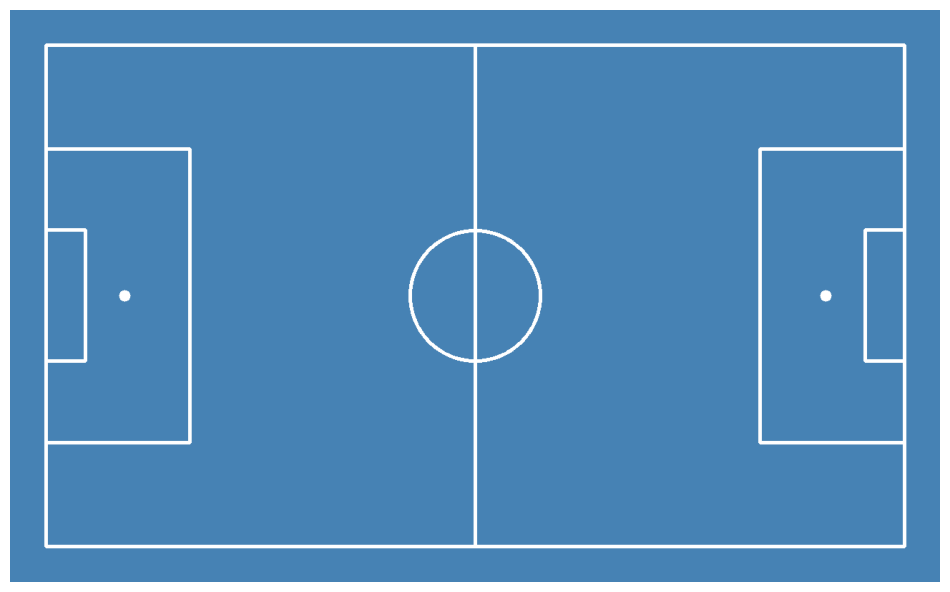

In [ ]:
CONFIG = SoccerPitchConfiguration()


annotated_frame = draw_pitch(CONFIG,
           background_color=sv.Color(70, 130, 180),  # SteelBlue
           line_color=sv.Color.WHITE)

sv.plot_image(annotated_frame)

In [ ]:
from huggingface_hub import login
login(token=userdata.get("HF_TOKEN"))

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '68f477753d26bc12cb03afc4', 'name': 'abhisp05', 'fullname': 'Abhijna SP', 'isPro': False, 'avatarUrl': '/avatars/8b7116828df169dd4e69b098db17919c.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'Football', 'role': 'fineGrained', 'createdAt': '2025-10-19T05:34:03.510Z', 'fineGrained': {'canReadGatedRepos': False, 'global': [], 'scoped': [{'entity': {'_id': '68f477753d26bc12cb03afc4', 'type': 'user', 'name': 'abhisp05'}, 'permissions': []}]}}}}


In [ ]:
import torch
from transformers import SiglipVisionModel, AutoProcessor

# Test load
model = SiglipVisionModel.from_pretrained('google/siglip-large-patch16-384')
processor = AutoProcessor.from_pretrained('google/siglip-large-patch16-384')

print("✅ Loaded successfully! Model:", model.config.model_type)

config.json:   0%|          | 0.00/554 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Loaded successfully! Model: siglip_vision_model


In [ ]:
# @title
V = TypeVar("V")

SIGLIP_MODEL_PATH = 'google/siglip-base-patch16-224'
#SIGLIP_MODEL_PATH = 'google/siglip-large-patch16-384'


def create_batches(
    sequence: Iterable[V], batch_size: int
) -> Generator[List[V], None, None]:
    """
    Generate batches from a sequence with a specified batch size.

    Args:
        sequence (Iterable[V]): The input sequence to be batched.
        batch_size (int): The size of each batch.

    Yields:
        Generator[List[V], None, None]: A generator yielding batches of the input
            sequence.
    """
    batch_size = max(batch_size, 1)
    current_batch = []
    for element in sequence:
        if len(current_batch) == batch_size:
            yield current_batch
            current_batch = []
        current_batch.append(element)
    if current_batch:
        yield current_batch


class TeamClassifier:
    """
    A classifier that uses a pre-trained SiglipVisionModel for feature extraction,
    UMAP for dimensionality reduction, and KMeans for clustering.
    """
    def __init__(self, device: str = 'cpu', batch_size: int = 32):
        """
       Initialize the TeamClassifier with device and batch size.

       Args:
           device (str): The device to run the model on ('cpu' or 'cuda').
           batch_size (int): The batch size for processing images.
       """
        self.device = device
        self.batch_size = batch_size
        self.features_model = SiglipVisionModel.from_pretrained(
            SIGLIP_MODEL_PATH).to(device)
        self.processor = AutoProcessor.from_pretrained(SIGLIP_MODEL_PATH)
        self.reducer = umap.UMAP(n_components=3)
        self.cluster_model = KMeans(n_clusters=2)

    def extract_features(self, crops: List[np.ndarray]) -> np.ndarray:
        """
        Extract features from a list of image crops using the pre-trained
            SiglipVisionModel.

        Args:
            crops (List[np.ndarray]): List of image crops.

        Returns:
            np.ndarray: Extracted features as a numpy array.
        """
        crops = [sv.cv2_to_pillow(crop) for crop in crops]
        batches = create_batches(crops, self.batch_size)
        data = []
        with torch.no_grad():
            for batch in tqdm(batches, desc='Embedding extraction'):
                inputs = self.processor(
                    images=batch, return_tensors="pt").to(self.device)
                outputs = self.features_model(**inputs)
                embeddings = torch.mean(outputs.last_hidden_state, dim=1).cpu().numpy()
                data.append(embeddings)

        return np.concatenate(data)

    def fit(self, crops: List[np.ndarray]) -> None:
        """
        Fit the classifier model on a list of image crops.

        Args:
            crops (List[np.ndarray]): List of image crops.
        """
        data = self.extract_features(crops)
        projections = self.reducer.fit_transform(data)
        self.cluster_model.fit(projections)

    def predict(self, crops: List[np.ndarray]) -> np.ndarray:
        """
        Predict the cluster labels for a list of image crops.

        Args:
            crops (List[np.ndarray]): List of image crops.

        Returns:
            np.ndarray: Predicted cluster labels.
        """
        if len(crops) == 0:
            return np.array([])

        data = self.extract_features(crops)
        projections = self.reducer.transform(data)
        return self.cluster_model.predict(projections)

In [ ]:
# @title
class ViewTransformer:
    def __init__(
            self,
            source: npt.NDArray[np.float32],
            target: npt.NDArray[np.float32]
    ) -> None:
        """
        Initialize the ViewTransformer with source and target points.

        Args:
            source (npt.NDArray[np.float32]): Source points for homography calculation.
            target (npt.NDArray[np.float32]): Target points for homography calculation.

        Raises:
            ValueError: If source and target do not have the same shape or if they are
                not 2D coordinates.
        """
        if source.shape != target.shape:
            raise ValueError("Source and target must have the same shape.")
        if source.shape[1] != 2:
            raise ValueError("Source and target points must be 2D coordinates.")

        source = source.astype(np.float32)
        target = target.astype(np.float32)
        self.m, _ = cv2.findHomography(source, target)
        if self.m is None:
            raise ValueError("Homography matrix could not be calculated.")

    def transform_points(
            self,
            points: npt.NDArray[np.float32]
    ) -> npt.NDArray[np.float32]:
        """
        Transform the given points using the homography matrix.

        Args:
            points (npt.NDArray[np.float32]): Points to be transformed.

        Returns:
            npt.NDArray[np.float32]: Transformed points.

        Raises:
            ValueError: If points are not 2D coordinates.
        """
        if points.size == 0:
            return points

        if points.shape[1] != 2:
            raise ValueError("Points must be 2D coordinates.")

        reshaped_points = points.reshape(-1, 1, 2).astype(np.float32)
        transformed_points = cv2.perspectiveTransform(reshaped_points, self.m)
        return transformed_points.reshape(-1, 2).astype(np.float32)

    def transform_image(
            self,
            image: npt.NDArray[np.uint8],
            resolution_wh: Tuple[int, int]
    ) -> npt.NDArray[np.uint8]:
        """
        Transform the given image using the homography matrix.

        Args:
            image (npt.NDArray[np.uint8]): Image to be transformed.
            resolution_wh (Tuple[int, int]): Width and height of the output image.

        Returns:
            npt.NDArray[np.uint8]: Transformed image.

        Raises:
            ValueError: If the image is not either grayscale or color.
        """
        if len(image.shape) not in {2, 3}:
            raise ValueError("Image must be either grayscale or color.")
        return cv2.warpPerspective(image, self.m, resolution_wh)

ViewTransformer (RANSAC-enabled) (Don't use made it worse here)

In [ ]:
# @title
"""import numpy as np
import numpy.typing as npt
import cv2
from typing import Tuple, Optional


class ViewTransformer:
    def __init__(
        self,
        source: npt.NDArray[np.float32],
        target: npt.NDArray[np.float32],
        ransac_thresh: float = 5.0,        # pixels – lower = stricter
        min_matches: int = 4               # need at least 4 inliers
    ) -> None:
        """
        Robust homography using RANSAC.

        Args:
            source: (N,2) points in camera image
            target: (N,2) points in top-down pitch (cm)
            ransac_thresh: max reprojection error for inlier (in pixels)
            min_matches: abort if fewer than this many inliers
        """
        if source.shape != target.shape or source.shape[1] != 2:
            raise ValueError("Source and target must be (N,2) arrays of same size.")

        source = source.astype(np.float32)
        target = target.astype(np.float32)

        # RANSAC + LMEDS fallback
        self.m, mask = cv2.findHomography(
            source, target,
            method=cv2.RANSAC,           # <--- THIS IS THE KEY LINE
            ransacReprojThreshold=ransac_thresh,
            maxIters=2000,
            confidence=0.995
        )

        if self.m is None:
            raise ValueError("Homography failed to compute.")

        inliers = int(mask.sum())
        if inliers < min_matches:
            raise ValueError(f"Only {inliers} inliers found. Need >= {min_matches}.")

        print(f"Homography computed with {inliers}/{len(source)} inliers")
        self.mask = mask.ravel().astype(bool)  # optional: keep for debugging

    # --- transform_points & transform_image stay the same ---
    def transform_points(self, points: npt.NDArray[np.float32]) -> npt.NDArray[np.float32]:
        if points.size == 0:
            return points
        if points.shape[1] != 2:
            raise ValueError("Points must be 2D.")
        reshaped = points.reshape(-1, 1, 2).astype(np.float32)
        transformed = cv2.perspectiveTransform(reshaped, self.m)
        return transformed.reshape(-1, 2)

    def transform_image(
        self,
        image: npt.NDArray[np.uint8],
        resolution_wh: Tuple[int, int]
    ) -> npt.NDArray[np.uint8]:
        if len(image.shape) not in {2, 3}:
            raise ValueError("Image must be grayscale or color.")
        return cv2.warpPerspective(image, self.m, resolution_wh)"""

IndentationError: unexpected indent (ipython-input-1627121907.py, line 17)

In [ ]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/Football-Mini-Map-Visualisation/models/runs/detect/train/weights/best.pt"
PLAYER_DETECTION_MODEL = YOLO(MODEL_PATH)

In [ ]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/Football-Mini-Map-Visualisation/models/keypoint-model/runs/pose/train/weights/best.pt"
FIELD_DETECTION_MODEL = YOLO(MODEL_PATH)

In [ ]:
"""from inference import get_model
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
PLAYER_DETECTION_MODEL_ID = "football-players-detection-3zvbc/11"
PLAYER_DETECTION_MODEL = get_model(model_id=PLAYER_DETECTION_MODEL_ID, api_key=ROBOFLOW_API_KEY)"""

In [ ]:
"""from inference import get_model
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
FIELD_DETECTION_MODEL_ID = "football-field-detection-f07vi/14"
FIELD_DETECTION_MODEL = get_model(model_id=FIELD_DETECTION_MODEL_ID, api_key=ROBOFLOW_API_KEY)"""

In [ ]:
# @title
import numpy as np
import supervision as sv

def resolve_goalkeepers_team_id(
    players: sv.Detections,
    goalkeepers: sv.Detections
) -> np.ndarray:
    goalkeepers_xy = goalkeepers.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    players_xy = players.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    team_0_centroid = players_xy[players.class_id == 0].mean(axis=0)
    team_1_centroid = players_xy[players.class_id == 1].mean(axis=0)
    goalkeepers_team_id = []
    for goalkeeper_xy in goalkeepers_xy:
        dist_0 = np.linalg.norm(goalkeeper_xy - team_0_centroid)
        dist_1 = np.linalg.norm(goalkeeper_xy - team_1_centroid)
        goalkeepers_team_id.append(0 if dist_0 < dist_1 else 1)

    return np.array(goalkeepers_team_id)

In [ ]:
# @title
SOURCE_VIDEO_PATH = "/content/121364_0.mp4"
PLAYER_ID = 2
STRIDE = 30

frame_generator = sv.get_video_frames_generator(
    source_path=SOURCE_VIDEO_PATH, stride=STRIDE)

crops = []
for frame in tqdm(frame_generator, desc='collecting crops'):
    result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)
    players_detections = detections[detections.class_id == PLAYER_ID]
    players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
    crops += players_crops

team_classifier = TeamClassifier(device="cuda")
team_classifier.fit(crops)

collecting crops: 25it [00:21,  1.14it/s]
Embedding extraction: 16it [00:07,  2.00it/s]


Embedding extraction: 1it [00:00,  3.89it/s]


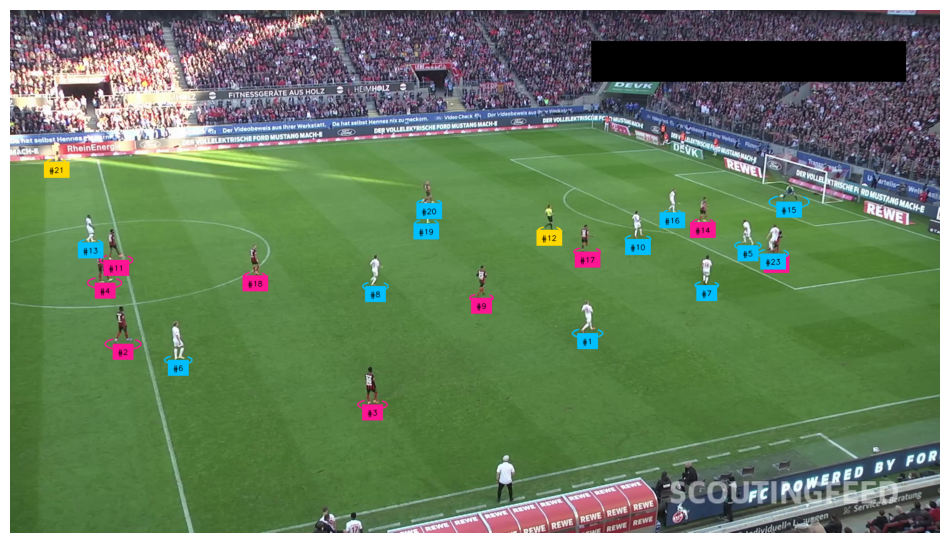

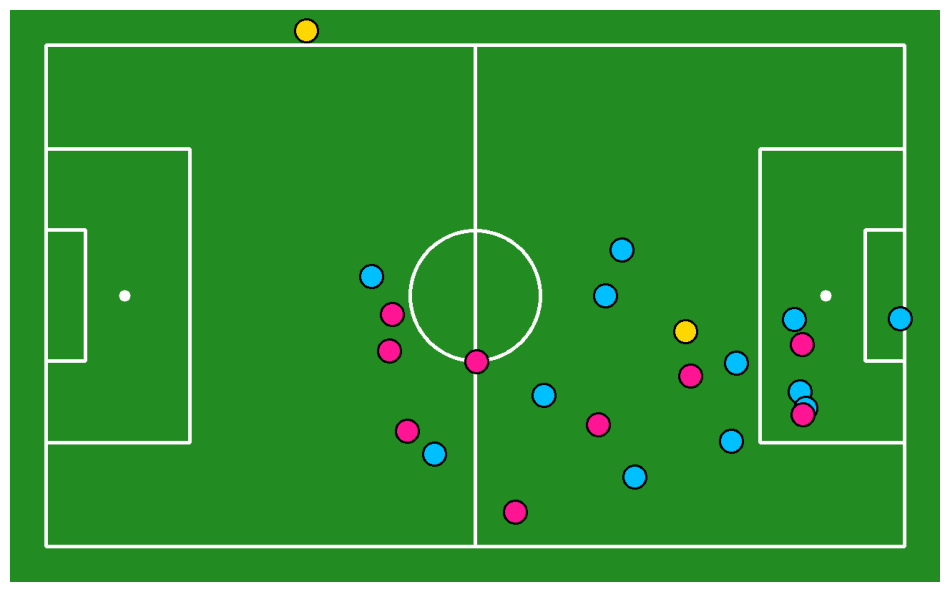

In [ ]:
# @title
SOURCE_VIDEO_PATH = "/content/573e61_0.mp4"
BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)
triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=20, height=17
)

tracker = sv.ByteTrack()
tracker.reset()

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# ball, goalkeeper, player, referee detection

result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)

ball_detections = detections[detections.class_id == BALL_ID]
ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

all_detections = detections[detections.class_id != BALL_ID]
all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)
all_detections = tracker.update_with_detections(detections=all_detections)

goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
players_detections = all_detections[all_detections.class_id == PLAYER_ID]
referees_detections = all_detections[all_detections.class_id == REFEREE_ID]

# team assignment

players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
players_detections.class_id = team_classifier.predict(players_crops)

goalkeepers_detections.class_id = resolve_goalkeepers_team_id(
    players_detections, goalkeepers_detections)

referees_detections.class_id -= 1

all_detections = sv.Detections.merge([
    players_detections, goalkeepers_detections, referees_detections])

# frame visualization

labels = [
    f"#{tracker_id}"
    for tracker_id
    in all_detections.tracker_id
]

all_detections.class_id = all_detections.class_id.astype(int)

annotated_frame = frame.copy()
annotated_frame = ellipse_annotator.annotate(
    scene=annotated_frame,
    detections=all_detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=all_detections,
    labels=labels)
annotated_frame = triangle_annotator.annotate(
    scene=annotated_frame,
    detections=ball_detections)

sv.plot_image(annotated_frame)

players_detections = sv.Detections.merge([
    players_detections, goalkeepers_detections
])

# detect pitch key points

result = FIELD_DETECTION_MODEL.predict(frame, conf=0.3, verbose=False)[0]
key_points = sv.KeyPoints.from_ultralytics(result)

# project ball, players and referies on pitch

filter = key_points.confidence[0] > 0.5
frame_reference_points = key_points.xy[0][filter]
pitch_reference_points = np.array(CONFIG.vertices)[filter]

transformer = ViewTransformer(
    source=frame_reference_points,
    target=pitch_reference_points
)

frame_ball_xy = ball_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
pitch_ball_xy = transformer.transform_points(points=frame_ball_xy)

players_xy = players_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
pitch_players_xy = transformer.transform_points(points=players_xy)

referees_xy = referees_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
pitch_referees_xy = transformer.transform_points(points=referees_xy)

# visualize video game-style radar view

annotated_frame = draw_pitch(CONFIG)
annotated_frame = draw_points_on_pitch(
    config=CONFIG,
    xy=pitch_ball_xy,
    face_color=sv.Color.WHITE,
    edge_color=sv.Color.BLACK,
    radius=10,
    pitch=annotated_frame)
annotated_frame = draw_points_on_pitch(
    config=CONFIG,
    xy=pitch_players_xy[players_detections.class_id == 0],
    face_color=sv.Color.from_hex('00BFFF'),
    edge_color=sv.Color.BLACK,
    radius=16,
    pitch=annotated_frame)
annotated_frame = draw_points_on_pitch(
    config=CONFIG,
    xy=pitch_players_xy[players_detections.class_id == 1],
    face_color=sv.Color.from_hex('FF1493'),
    edge_color=sv.Color.BLACK,
    radius=16,
    pitch=annotated_frame)
annotated_frame = draw_points_on_pitch(
    config=CONFIG,
    xy=pitch_referees_xy,
    face_color=sv.Color.from_hex('FFD700'),
    edge_color=sv.Color.BLACK,
    radius=16,
    pitch=annotated_frame)

sv.plot_image(annotated_frame)

In [ ]:
BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3

In [ ]:
class TeamConsistencyTracker:
    def __init__(self, history_length=10, confidence_threshold=0.7):
        self.history_length = history_length
        self.confidence_threshold = confidence_threshold
        self.player_team_history = defaultdict(list)
        self.team_assignments = {}

    def update_team_assignment(self, tracker_id, current_team_prediction):
        # Add current prediction to history
        self.player_team_history[tracker_id].append(current_team_prediction)

        # Keep only recent history
        if len(self.player_team_history[tracker_id]) > self.history_length:
            self.player_team_history[tracker_id].pop(0)

        # Get most common team in history
        history = self.player_team_history[tracker_id]
        if len(history) >= 3:  # Wait for some history to accumulate
            team_counts = np.bincount(history)
            most_common_team = np.argmax(team_counts)
            confidence = team_counts[most_common_team] / len(history)

            if confidence >= self.confidence_threshold:
                self.team_assignments[tracker_id] = most_common_team
                return most_common_team

        # If not enough confidence, use current prediction
        return current_team_prediction

    def get_stable_team(self, tracker_id, current_team_prediction):
        if tracker_id in self.team_assignments:
            return self.team_assignments[tracker_id]
        return current_team_prediction

In [ ]:
team_tracker = TeamConsistencyTracker(history_length=15, confidence_threshold=0.8)

# Initialize annotators (same as before)
ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)
triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=20, height=17
)

tracker = sv.ByteTrack()


In [ ]:
def create_mini_map(frame, ball_detections, players_detections, referees_detections, goalkeepers_detections):
    """Create mini map with pitch and player positions"""
    try:
        # Detect pitch key points
        result = FIELD_DETECTION_MODEL.predict(frame, conf=0.3, verbose=False)[0]
        key_points = sv.KeyPoints.from_ultralytics(result)

        # Project ball, players and referees on pitch
        filter = key_points.confidence[0] > 0.5
        if np.sum(filter) < 4:
            return None

        frame_reference_points = key_points.xy[0][filter]
        pitch_reference_points = np.array(CONFIG.vertices)[filter]

        transformer = ViewTransformer(
            source=frame_reference_points,
            target=pitch_reference_points
        )

        # Transform positions to pitch coordinates
        frame_ball_xy = ball_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
        pitch_ball_xy = transformer.transform_points(points=frame_ball_xy) if len(frame_ball_xy) > 0 else np.array([])

        all_players_detections = sv.Detections.merge([players_detections, goalkeepers_detections])
        players_xy = all_players_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
        pitch_players_xy = transformer.transform_points(points=players_xy) if len(players_xy) > 0 else np.array([])

        referees_xy = referees_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
        pitch_referees_xy = transformer.transform_points(points=referees_xy) if len(referees_xy) > 0 else np.array([])

        # Create mini map
        mini_map = draw_pitch(CONFIG)

        # Draw players (team 0 - blue)
        if len(pitch_players_xy) > 0:
            team_0_mask = all_players_detections.class_id == 0
            if np.any(team_0_mask):
                mini_map = draw_points_on_pitch(
                    config=CONFIG,
                    xy=pitch_players_xy[team_0_mask],
                    face_color=sv.Color.from_hex('00BFFF'),
                    edge_color=sv.Color.BLACK,
                    radius=16,
                    pitch=mini_map)

        # Draw players (team 1 - pink)
        if len(pitch_players_xy) > 0:
            team_1_mask = all_players_detections.class_id == 1
            if np.any(team_1_mask):
                mini_map = draw_points_on_pitch(
                    config=CONFIG,
                    xy=pitch_players_xy[team_1_mask],
                    face_color=sv.Color.from_hex('FF1493'),
                    edge_color=sv.Color.BLACK,
                    radius=16,
                    pitch=mini_map)

        # Draw referees (yellow)
        if len(pitch_referees_xy) > 0:
            mini_map = draw_points_on_pitch(
                config=CONFIG,
                xy=pitch_referees_xy,
                face_color=sv.Color.from_hex('FFD700'),
                edge_color=sv.Color.BLACK,
                radius=16,
                pitch=mini_map)

        # Draw ball (white)
        if len(pitch_ball_xy) > 0:
            mini_map = draw_points_on_pitch(
                config=CONFIG,
                xy=pitch_ball_xy,
                face_color=sv.Color.WHITE,
                edge_color=sv.Color.BLACK,
                radius=10,
                pitch=mini_map)

        return mini_map
    except Exception as e:
        print(f"Error creating mini map: {e}")
        return None

In [ ]:
# @title
def overlay_mini_map(main_frame, mini_map, position='bottom_right', scale=0.2):
    """Overlay mini map on the main frame"""
    if mini_map is None:
        return main_frame

    h_main, w_main = main_frame.shape[:2]
    h_mini, w_mini = mini_map.shape[:2]

    # Calculate scaled dimensions
    new_width = int(w_main * scale)
    new_height = int((h_mini / w_mini) * new_width)

    # Resize mini map
    mini_map_resized = cv2.resize(mini_map, (new_width, new_height))

    # Calculate position
    if position == 'bottom_right':
        x_offset = w_main - new_width - 10
        y_offset = h_main - new_height - 10
    elif position == 'bottom_left':
        x_offset = 10
        y_offset = h_main - new_height - 10
    elif position == 'top_right':
        x_offset = w_main - new_width - 10
        y_offset = 10
    else:  # top_left
        x_offset = 10
        y_offset = 10

    # Ensure coordinates are within bounds
    x_offset = max(0, min(x_offset, w_main - new_width))
    y_offset = max(0, min(y_offset, h_main - new_height))

    # Overlay mini map
    main_frame[y_offset:y_offset+new_height, x_offset:x_offset+new_width] = mini_map_resized

    # Add border
    border_thickness = 2
    cv2.rectangle(main_frame,
                 (x_offset, y_offset),
                 (x_offset+new_width, y_offset+new_height),
                 (255, 255, 255), border_thickness)

    return main_frame

In [ ]:
def process_frame(frame: np.ndarray, _) -> np.ndarray:
    # Run inference for player detection
    result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)

    # Process ball detections
    ball_detections = detections[detections.class_id == BALL_ID]
    ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

    # Process other detections
    all_detections = detections[detections.class_id != BALL_ID]
    all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)
    all_detections = tracker.update_with_detections(detections=all_detections)

    # Separate different object types
    goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
    players_detections = all_detections[all_detections.class_id == PLAYER_ID]
    referees_detections = all_detections[all_detections.class_id == REFEREE_ID]

    # Team assignment with stabilization
    players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
    if players_crops:
        current_team_predictions = team_classifier.predict(players_crops)

        # Apply team consistency tracking
        stabilized_team_ids = []
        for i, tracker_id in enumerate(players_detections.tracker_id):
            if tracker_id is not None:
                stabilized_team = team_tracker.update_team_assignment(
                    tracker_id, current_team_predictions[i])
                stabilized_team_ids.append(stabilized_team)
            else:
                stabilized_team_ids.append(current_team_predictions[i])

        players_detections.class_id = np.array(stabilized_team_ids)

    # Stabilize goalkeeper teams
    goalkeepers_detections.class_id = resolve_goalkeepers_team_id(
        players_detections, goalkeepers_detections)

    referees_detections.class_id -= 1

    all_detections = sv.Detections.merge([
        players_detections, goalkeepers_detections, referees_detections])

    # Create labels
    labels = [
        f"#{tracker_id}"
        for tracker_id
        in all_detections.tracker_id
    ]

    all_detections.class_id = all_detections.class_id.astype(int)

    # Annotate main frame
    annotated_frame = frame.copy()
    annotated_frame = ellipse_annotator.annotate(
        scene=annotated_frame,
        detections=all_detections)
    annotated_frame = label_annotator.annotate(
        scene=annotated_frame,
        detections=all_detections,
        labels=labels)
    annotated_frame = triangle_annotator.annotate(
        scene=annotated_frame,
        detections=ball_detections)

    # Create and overlay mini map
    mini_map = create_mini_map(frame, ball_detections, players_detections,
                              referees_detections, goalkeepers_detections)
    if mini_map is not None:
        annotated_frame = overlay_mini_map(annotated_frame, mini_map,
                                         position='bottom_right', scale=0.2)

    return annotated_frame

In [ ]:
SOURCE_VIDEO_PATH = "/content/121364_0.mp4"
TARGET_VIDEO_PATH = "/content/121364_0stabilizednew.mp4"

sv.process_video(
    source_path=SOURCE_VIDEO_PATH,
    target_path=TARGET_VIDEO_PATH,
    callback=process_frame
)

print(f"Video processing complete! Stabilized video saved to: {TARGET_VIDEO_PATH}")

Embedding extraction: 1it [00:00,  9.30it/s]
Embedding extraction: 1it [00:00,  3.45it/s]
Embedding extraction: 1it [00:00,  3.62it/s]
Embedding extraction: 1it [00:00,  3.53it/s]
Embedding extraction: 1it [00:00,  2.82it/s]
Embedding extraction: 1it [00:00,  3.36it/s]
Embedding extraction: 1it [00:00,  3.18it/s]
Embedding extraction: 1it [00:00,  2.60it/s]
Embedding extraction: 1it [00:00,  3.35it/s]
Embedding extraction: 1it [00:00,  3.94it/s]
Embedding extraction: 1it [00:00,  3.96it/s]
Embedding extraction: 1it [00:00,  3.91it/s]
Embedding extraction: 1it [00:00,  3.95it/s]
Embedding extraction: 1it [00:00,  3.96it/s]
Embedding extraction: 1it [00:00,  4.03it/s]
Embedding extraction: 1it [00:00,  4.01it/s]
Embedding extraction: 1it [00:00,  3.96it/s]
Embedding extraction: 1it [00:00,  3.75it/s]
Embedding extraction: 1it [00:00,  3.94it/s]
Embedding extraction: 1it [00:00,  3.98it/s]
Embedding extraction: 1it [00:00,  3.94it/s]
Embedding extraction: 1it [00:00,  3.88it/s]
Embedding 

Video processing complete! Stabilized video saved to: /content/121364_0stabilizednew.mp4
